# Analyses of drug data from group #6

To do
- ~~Analyze lick data~~
    - ~~RT~~
    - ~~Lick rate~~
    - ~~ILI~~
- History kernels
- ~~Add HMM~~
- Repeating bias per ILD

In [1]:
# Standard
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import ttest_ind, ttest_rel

# Own
from glue_sessions.glue_sessions import *
from intersession import glue_animals_intersessions
from my_fun import *
from licks.licks import *
from psychometric_curves import *
from kernels.psychophysical_kernels import *
from full_model_behavior import *
from plotting_style import *
from drugs import *

ModuleNotFoundError: No module named 'statsmodels'

In [3]:
# Magics
%load_ext autoreload
%autoreload 2
# %matplotlib inline
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'

In [4]:
# Plotting style
# sns.set_theme()
sns.set_style('ticks')
# sns.set_context('poster')
# sns.set_context('notebook')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
# default_figsize = np.array(plt.rcParams['figure.figsize'])

# Load behavioral data

In [5]:
# Set parameters
experiment = '2AFC_6'  # Drug

# Load trial data (lick analyses)
df_behavior = glue_animals(experiment=experiment, path_session='glue_sessions', filter_drug=False, update=False, to_csv=False)  # Raw
# df_behavior = glue_animals(experiment=experiment, path_session='glmhmm/2_states', filter_drug=False, update=False, to_csv=False)  # GLM HMM fits

# Load intersession data
df_intersessions = glue_animals_intersessions(experiment=experiment, update=False, to_csv=False)

# 0 pad subject ID (this batches start with 0 so IDs are read as ints instead of 3 character length str)
df_behavior.Subject = df_behavior.Subject.astype(str)
df_behavior['Subject'] = df_behavior['Subject'].str.zfill(3)
df_intersessions.Subject = df_intersessions.Subject.astype(str)
df_intersessions['Subject'] = df_intersessions['Subject'].str.zfill(3)

Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6


# Filter data

In [6]:
animals = main([experiment])[experiment]
df_behavior = df_behavior[df_behavior.Task == 'FD'].reset_index(drop=True)
df_behavior = df_behavior[df_behavior.P > 0].reset_index(drop=True)

# Remove subjects not in cherries
df_behavior = df_behavior[df_behavior.Subject.isin(animals)].reset_index(drop=True)
df_intersessions = df_intersessions[df_intersessions.Subject.isin(animals)].reset_index(drop=True)
assert df_behavior.Subject.unique().tolist() == animals

# Remove the AW and Warm Up trials
_ = len(df_behavior)
df_behavior = clean_session_start(df_behavior)
print(f'Removed {(_ - len(df_behavior))} trials from session start (AW and Warm Up trials)')

print(f'{round(len(df_behavior) / 1000)}k trials')

Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Filtering paired saline-drug sessions for experiment 2AFC_6
Cherry picking for experiment: 2AFC_6
Number of responded trials in data collection (with evidences):
14: 4277 trials
16: 5850 trials
17: 6533 trials
18: 3016 trials
19: 2479 trials
20: 7268 trials
22: 5208 trials
23: 54

In [7]:
# Remove bad sessions

# Add paired session index
n_paired_sessions = len(df_intersessions) // 2
print(f'Total: {n_paired_sessions:.0f} paired sessions')
paired_sessions = np.repeat(np.arange(n_paired_sessions), 2)
df_intersessions['PairedSession'] = paired_sessions

threshold = 0.5  # Accuracy threshold. Drop in accuracy expected and a result, use very lax value
mask = df_intersessions.Accuracy < threshold
# mask = ((df_intersessions.AccuracyLeft < threshold) | (df_intersessions.AccuracyRight < threshold))

# Remove from intersession data
bad_sessions = df_intersessions[mask].PairedSession
bad_sessions = bad_sessions.unique()
print(f'{len(bad_sessions)} bad paired sessions. Pair indexes: {bad_sessions}')
print(df_intersessions.loc[df_intersessions.PairedSession.isin(bad_sessions), ['PairedSession', 'Accuracy', 'AccuracyLeft', 'AccuracyRight']])
df_intersessions = df_intersessions[~df_intersessions.PairedSession.isin(bad_sessions)].reset_index(drop=True)
print(f'Dropped {np.round((len(bad_sessions) / n_paired_sessions)*100, 2)}% paired sessions')

# # Remove from trial data (merging with already filtered intersession data)
# df_behavior['Date'] = pd.to_datetime(df_behavior['Date'])
# df_behavior = df_behavior.merge(
#     df_intersessions[['Subject', 'Dates', 'PairedSession']],
#     left_on=['Subject', 'Date'],
#     right_on=['Subject', 'Dates'],
#     how='left'
# )
#
# # Optionally, drop the extra 'Date' column from df_intersession after merging
# df_behavior = df_behavior.drop(columns='Dates')

Total: 81 paired sessions
6 bad paired sessions. Pair indexes: [33 60 61 62 71 80]
     PairedSession  Accuracy  AccuracyLeft  AccuracyRight
66              33  0.480392      0.926174       0.057325
67              33  0.501730      0.979021       0.034247
120             60  0.611111      0.328125       0.866197
121             60  0.476190      0.208861       0.786765
122             61  0.572347      0.292683       0.884354
123             61  0.462633      0.013699       0.948148
124             62  0.520767      0.618750       0.418301
125             62  0.472131      0.951389       0.043478
142             71  0.464151      0.924370       0.089041
143             71  0.525180      0.893939       0.191781
160             80  0.580645      0.849315       0.341463
161             80  0.474026      0.420382       0.529801
Dropped 7.41% paired sessions


In [8]:
n_subjects = df_behavior.Subject.nunique()
n_paired_sessions = len(df_intersessions) // 2
n_trials = len(df_behavior)
n_trials_saline = len(df_behavior[df_behavior.Drug == 0])
n_trials_drug = len(df_behavior[df_behavior.Drug == 1])
print(f'N subjects = {n_subjects}')
print(f'N paired sessions = {n_paired_sessions}')
print(f'N trials = {n_trials} (saline: {n_trials_saline}, drug: {n_trials_drug}')

N subjects = 10
N paired sessions = 75
N trials = 46184 (saline: 23132, drug: 23052


# Behavioral metrics

## Standard

In [10]:
# df_intersessions['AbsLatBias'] = abs(df_intersessions.LateralBias)  # Add new column
# figsize = fig_size(n_cols=3)
# # plot_var_drug(df_intersessions, var_name='Accuracy', figsize=figsize)
# plot_var_drug(df_intersessions, var_name='AccMaxEvi', figsize=figsize)
# plot_var_drug(df_intersessions, var_name='AccNonMaxEvi', figsize=figsize)
# plot_var_drug(df_intersessions, var_name='LateralBias', figsize=figsize)
# plot_var_drug(df_intersessions, var_name='AbsLatBias', figsize=figsize)
# plot_var_drug(df_intersessions, var_name='MissRate', figsize=figsize)
# plot_var_drug(df_intersessions, var_name='CorrRepBias', figsize=figsize)

## Licks

In [7]:
subject = '016'  # Example mouse

### Add lick data

In [9]:
# Save old columns for comparison later
old_columns = list(df_behavior.columns)

# Add lick data to the DataFrame
df_behavior = add_lick_data(df_behavior)

# Add session half index (0 for the 1st and 1 for the 2nd)
df_behavior['SessionHalf'] = (df_behavior.Trial >= df_behavior.groupby('Session').Trial.transform('max') / 2).astype(int)
# Add absolute ILD
loc = df_behavior.columns.get_loc('ILD') + 1
df_behavior.insert(loc, 'absILD', df_behavior['ILD'].abs())

# Print new columns added to the DataFrame
new_columns = list(df_behavior.columns)
new_columns = [col for col in new_columns if col not in old_columns]
print(new_columns)

# df_behavior.head()

3.86% of premature lick trials (before response window)
Port1In or Port2In are already lists
['absILD', 'LicksLeft', 'LicksRight', 'nLicksLeft', 'nLicksRight', 'nLicks', 'leftILI', 'rightILI', 'ILI', 'RT', 'RT2', 'SessionHalf']


In [10]:
# Correct 150 ms artifact in RT
# To do: hardcode it in the lick preprocessing pipeline (add_lick_data)
df_behavior.RT -= 0.15
df_behavior.RT = df_behavior.RT.clip(lower=0)

### RTs

Text(0.5, 1.0, 'Example mouse')

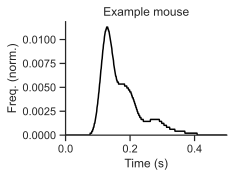

In [88]:
# Example mouse
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_dist(df_behavior[df_behavior.Subject==subject], var='RT', smooth=True, z=False, density=False, sem=True)
plt.title('Example mouse')

Text(0.5, 1.0, 'All mice')

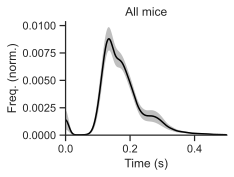

In [89]:
# Mean all mice
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_dist(df_behavior, var='RT', smooth=True, z=False, density=False, sem=True)
plt.title('All mice')

Text(0.5, 1.0, 'Example mouse')

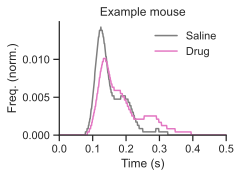

In [90]:
# Example mouse
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_split(df_behavior[df_behavior.Subject==subject], var='RT', split='drug', kind='hist')
plt.title('Example mouse')

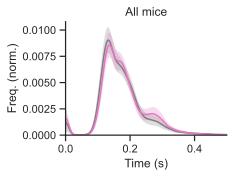

In [91]:
# Mean all mice
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_split(df_behavior, var='RT', split='drug', kind='hist')
plt.title('All mice')
plt.legend().remove()

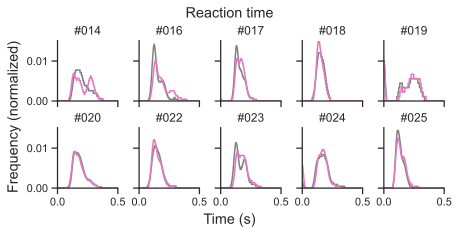

In [92]:
figsize = fig_size(n_cols=1)
figsize = (figsize[0], figsize[0]/2)
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, var='RT', split='drug', kind='hist', figsize=figsize)

In [93]:
# plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, var='RT', split='drug', kind='kde')

RT: t = -1.283, p = 0.231


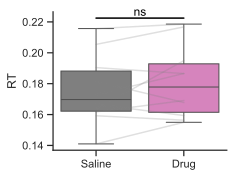

In [94]:
# Stats
figsize = fig_size(n_cols=2)
plot_var_drug(df_behavior, var_name='RT', figsize=figsize)

#### ILD

In [13]:
figsize = fig_size(n_cols=2)

##### All trials

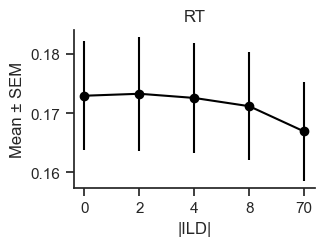

In [24]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior, var='RT')

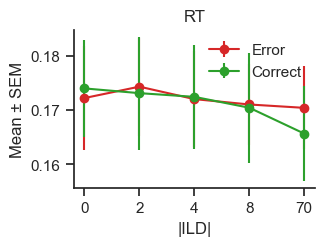

In [26]:
# Split by outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior, var='RT', split='outcome')

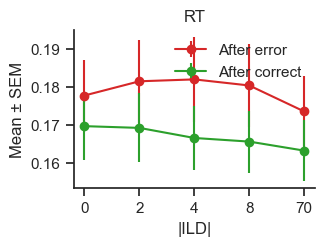

In [28]:
# Split by previous outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior, var='RT', split='prev_out')

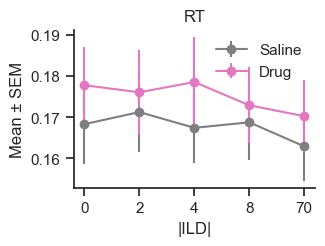

In [32]:
# Split by drug
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior, var='RT', split='drug')

##### Saline

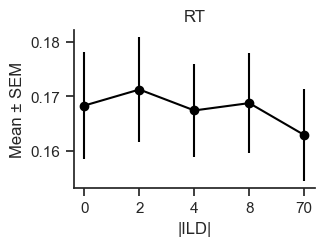

In [36]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==0], var='RT')

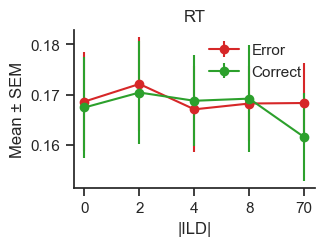

In [31]:
# Split by outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==0], var='RT', split='outcome')

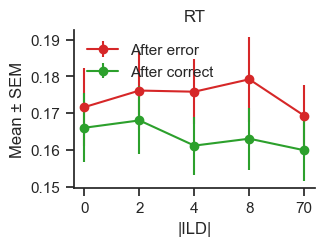

In [33]:
# Split by previous outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==0], var='RT', split='prev_out')

##### Drug

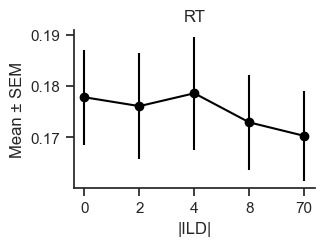

In [37]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==1], var='RT')

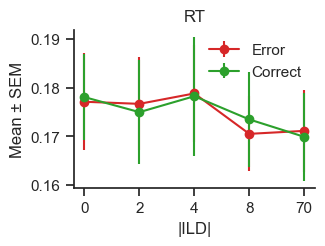

In [38]:
# Split by outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==1], var='RT', split='outcome')

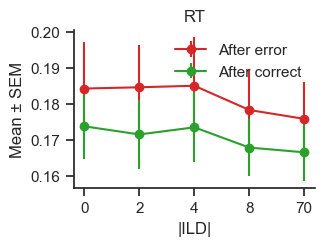

In [39]:
# Split by previous outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==1], var='RT', split='prev_out')

#### Model

Fitting GLM with Gaussian family for RT...
Including Drug as a predictor...
Fitting model for subject 014 (3895)...
Dropping 0 sessions with <50 trials:
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: RT       
No. Observations: 3678    Method:             REML     
No. Groups:       14      Scale:              0.0046   
Min. group size:  135     Log-Likelihood:     4605.3761
Max. group size:  290     Converged:          Yes      
Mean group size:  262.7                                
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.166    0.015 10.722 0.000  0.136  0.196
Choice        0.007    0.001  5.216 0.000  0.004  0.010
Hit           0.001    0.004  0.335 0.737 -0.007  0.009
AfterError    0.024    0.002 10.192 0.000  0.019  0.028
absILD        0.006    0.004  1.464 0.143 -0.002  0.013
absILD:Hit   -0.

Text(0, 0.5, 'Weight (s)')

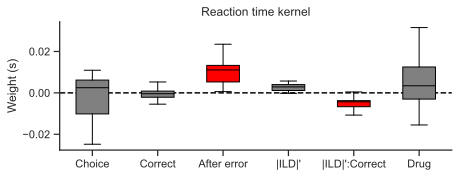

In [97]:
figsize = (fig_size(n_cols=1)[0], fig_size(n_cols=2)[1])
var = 'RT'
df_params, df_p = model_licks(df_behavior, var=var, drug=True, me=True)
plot_model_licks(df_params, df_p, kind='box', figsize=figsize)
plt.title('Reaction time kernel')
plt.ylabel('Weight (s)')

### Lick rate

Text(0.5, 1.0, 'Example mouse')

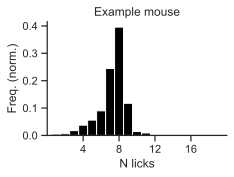

In [142]:
# Example mouse
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_dist(df_behavior[df_behavior.Hit==1][df_behavior.Subject==subject], var='nLicks', smooth=True, z=False, density=False, sem=True)
plt.title('Example mouse')

Text(0.5, 1.0, 'All mice')

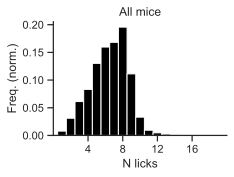

In [140]:
# Mean all mice
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_dist(df_behavior[df_behavior.Hit==1], var='nLicks', smooth=True, z=False, density=False, sem=True)
plt.title('All mice')

Text(0.5, 1.0, 'Example mouse')

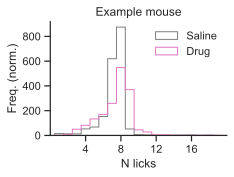

In [143]:
# Example mouse
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_split(df_behavior[df_behavior.Hit==1][df_behavior.Subject==subject], var='nLicks', split='drug', kind='hist')
plt.title('Example mouse')
# plt.legend(loc='lower center')

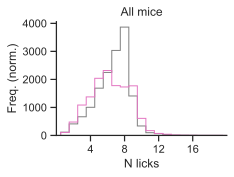

In [144]:
# Mean all mice
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='drug', kind='hist')
plt.title('All mice')
plt.legend().remove()

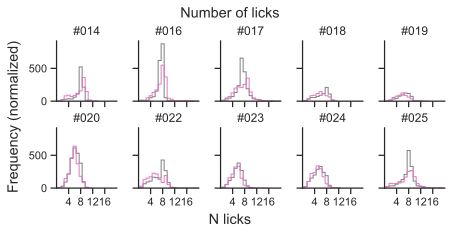

In [102]:
figsize = fig_size(n_cols=1)
figsize = (figsize[0], figsize[0]/2)
plot_licks_per_subject(df_behavior[df_behavior.Hit==1], plot_func=plot_licks_split, var='nLicks', split='drug', kind='hist', figsize=figsize)

nLicks: t = 2.708, p = 0.024


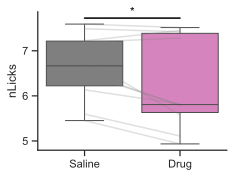

In [103]:
# Stats
figsize = fig_size(n_cols=2)
plot_var_drug(df_behavior[df_behavior.Hit==1], var_name='nLicks', figsize=figsize)

#### ILD

In [ ]:
figsize = fig_size(n_cols=2)

##### All trials

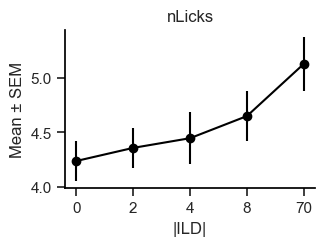

In [54]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior, var='nLicks')

This is simply reflecting the psyschometric behavior: the higher the ILD, the more correct choices, the more licks.

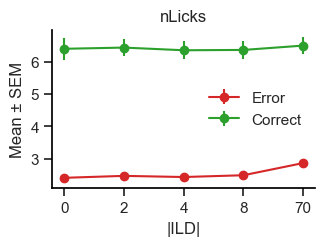

In [55]:
# Split by outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior, var='nLicks', split='outcome')

Since now on, current outcome will always be split

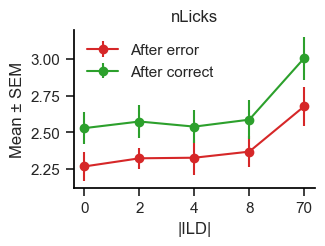

In [75]:
# Split by previous outcome (current error)
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Hit==0], var='nLicks', split='prev_out')

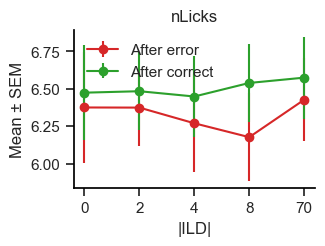

In [68]:
# Split by previous outcome (current correct)
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='prev_out')

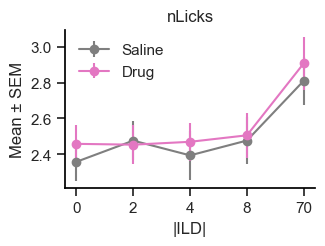

In [77]:
# Split by drug (current error)
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Hit==0], var='nLicks', split='drug')

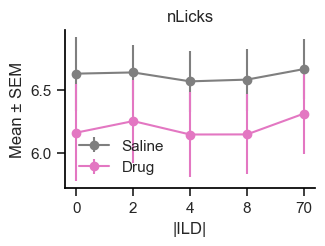

In [60]:
# Split by drug (current correct)
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='drug')

##### Saline

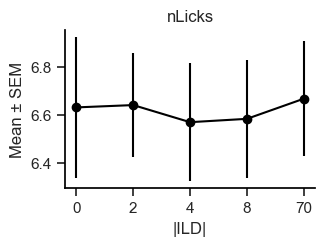

In [83]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==0][df_behavior.Hit==1], var='nLicks')

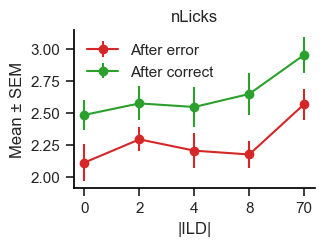

In [73]:
# Split by previous outcome (current error)
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==0][df_behavior.Hit==0], var='nLicks', split='prev_out')

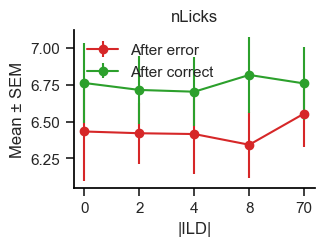

In [82]:
# Split by previous outcome (current correct)
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==0][df_behavior.Hit==1], var='nLicks', split='prev_out')

##### Drug

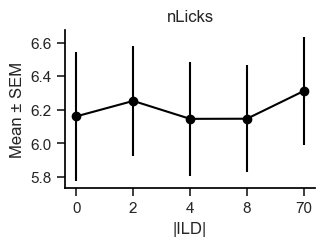

In [86]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==1][df_behavior.Hit==1], var='nLicks')

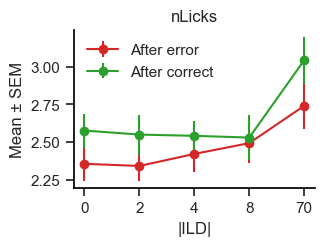

In [90]:
# Split by previous outcome (current error)
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==1][df_behavior.Hit==0], var='nLicks', split='prev_out')

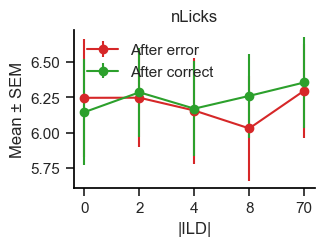

In [91]:
# Split by previous outcome (current correct)
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==1][df_behavior.Hit==1], var='nLicks', split='prev_out')

#### Model

Fitting GLM with Poisson family for nLicks...
Including Drug as a predictor...
Fitting model for subject 014 (3895)...
Dropping 0 sessions with <50 trials:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 nLicks   No. Observations:                 2202
Model:                            GLM   Df Residuals:                     2196
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4887.4
Date:                Thu, 23 Oct 2025   Deviance:                       1367.5
Time:                        18:19:20   Pearson chi2:                 1.17e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.02625
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|

Text(0, 0.5, 'Weight (N licks)')

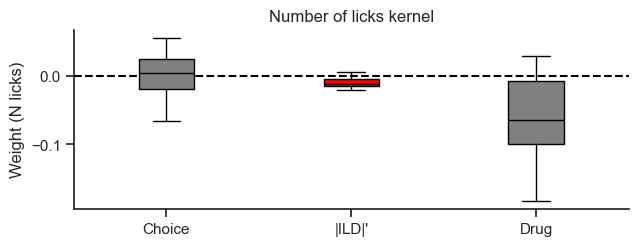

In [199]:
figsize = (fig_size(n_cols=1)[0], fig_size(n_cols=2)[1])
var = 'nLicks'
df_params, df_p = model_licks(df_behavior, var=var, drug=True, me=True)
plot_model_licks(df_params, df_p, kind='box', figsize=figsize)
plt.title('Number of licks kernel')
plt.ylabel('Weight (N licks)')

### ILI

Text(0.5, 1.0, 'Example mouse')

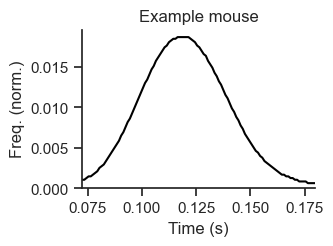

In [200]:
# Example mouse
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_dist(df_behavior[df_behavior.Subject==subject], var='ILI', smooth=True, z=False, density=False, sem=True)
plt.title('Example mouse')

Text(0.5, 1.0, 'All mice')

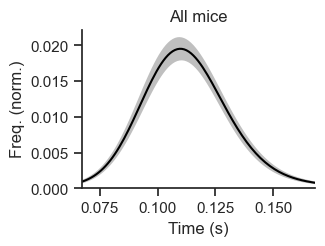

In [201]:
# Mean all mice
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_dist(df_behavior, var='ILI', smooth=True, z=False, density=False, sem=True)
plt.title('All mice')

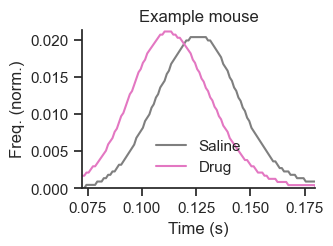

In [202]:
# Example mouse
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_split(df_behavior[df_behavior.Subject==subject], var='ILI', split='drug', kind='hist')
plt.title('Example mouse')
plt.legend(loc='lower center')

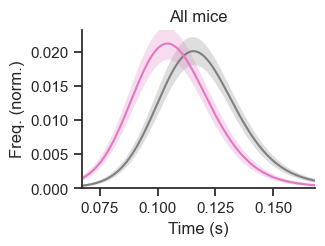

In [203]:
# Mean all mice
figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
plot_licks_split(df_behavior, var='ILI', split='drug', kind='hist')
plt.title('All mice')
plt.legend().remove()

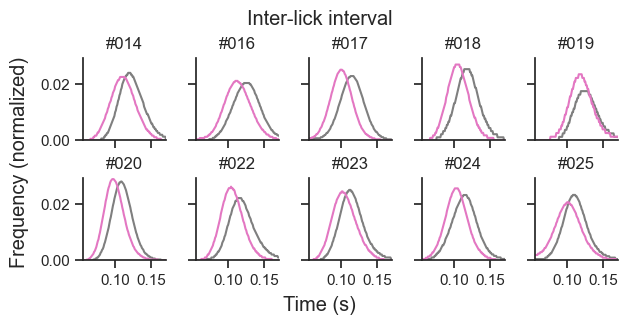

In [204]:
figsize = fig_size(n_cols=1)
figsize = (figsize[0], figsize[0]/2)
plot_licks_per_subject(df_behavior, plot_func=plot_licks_split, var='ILI', split='drug', kind='hist', figsize=figsize)

ILI: t = 11.746, p = 0.000


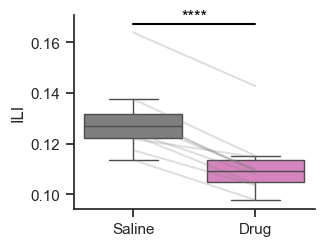

In [205]:
# Stats
figsize = fig_size(n_cols=2)
plot_var_drug(df_behavior, var_name='ILI', figsize=figsize)

#### ILD

In [ ]:
figsize = fig_size(n_cols=2)

##### All trials

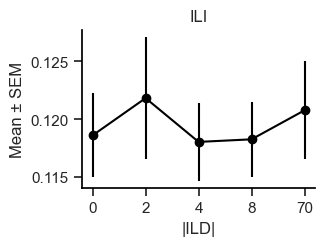

In [96]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior, var='ILI')

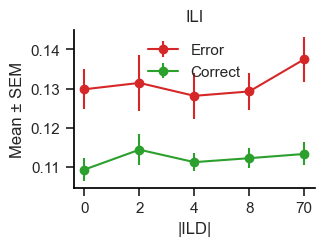

In [97]:
# Split by outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior, var='ILI', split='outcome')

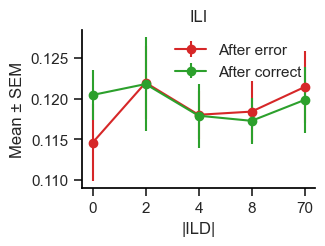

In [98]:
# Split by previous outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior, var='ILI', split='prev_out')

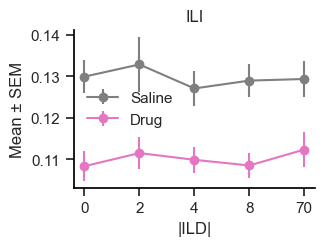

In [99]:
# Split by drug
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior, var='ILI', split='drug')

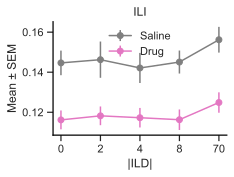

In [20]:
# Split by drug
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Hit==0], var='ILI', split='drug')

##### Saline

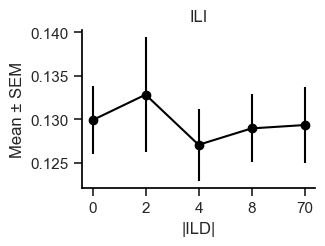

In [100]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==0], var='ILI')

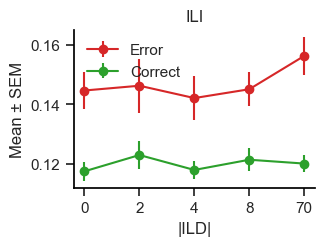

In [101]:
# Split by outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==0], var='ILI', split='outcome')

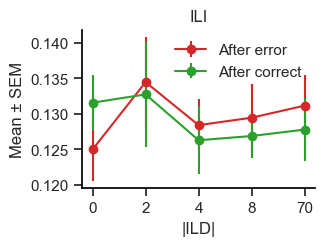

In [102]:
# Split by previous outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==0], var='ILI', split='prev_out')

##### Drug

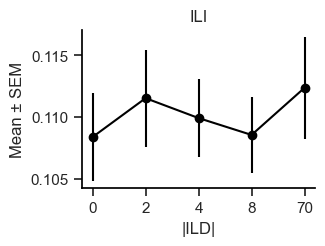

In [104]:
# All trials
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean(df_behavior[df_behavior.Drug==1], var='ILI')

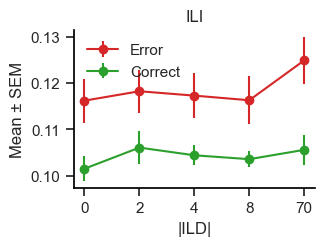

In [105]:
# Split by outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==1], var='ILI', split='outcome')

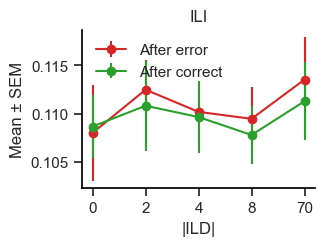

In [106]:
# Split by previous outcome
plt.figure(figsize=figsize, constrained_layout=True)
plot_ild_dist_mean_split(df_behavior[df_behavior.Drug==1], var='ILI', split='prev_out')

#### Model

Fitting GLM with Gaussian family for ILI...
Including Drug as a predictor...
Fitting model for subject 014 (3895)...
Dropping 0 sessions with <50 trials:
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ILI      
No. Observations: 3502    Method:             REML     
No. Groups:       14      Scale:              0.0017   
Min. group size:  124     Log-Likelihood:     6181.9426
Max. group size:  284     Converged:          Yes      
Mean group size:  250.1                                
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.143    0.004 33.368 0.000  0.134  0.151
Choice       -0.003    0.001 -3.338 0.001 -0.004 -0.001
Hit          -0.019    0.003 -7.673 0.000 -0.024 -0.014
AfterError    0.003    0.001  2.347 0.019  0.001  0.006
absILD        0.008    0.002  3.137 0.002  0.003  0.012
absILD:Hit   -0

Text(0, 0.5, 'Weight (s)')

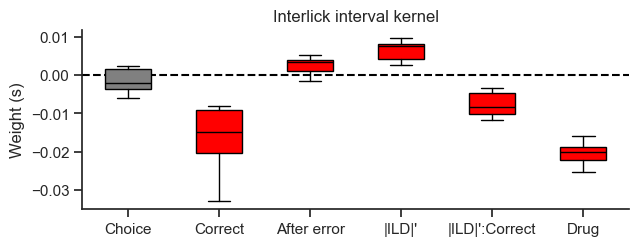

In [208]:
figsize = (fig_size(n_cols=1)[0], fig_size(n_cols=2)[1])
var = 'ILI'
df_params, df_p = model_licks(df_behavior, var=var, drug=True, me=True)
plot_model_licks(df_params, df_p, kind='box', figsize=figsize)
plt.title('Interlick interval kernel')
plt.ylabel('Weight (s)')

# Psychometrics

In [209]:
# Identify outliers per condition (same as Seaborn)
def remove_outliers(df, group_col, value_col):
    cleaned = []
    for name, group in df.groupby(group_col):
        Q1 = group[value_col].quantile(0.25)
        Q3 = group[value_col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        cleaned.append(group[(group[value_col] >= lower) & (group[value_col] <= upper)])
    return pd.concat(cleaned, axis=0)
def compare_psych_params(params, param_name, **kwargs):
    """
    Compare the parameters of the saline and drug conditions.
    """

    subject = np.tile(np.arange(len(params) // 2), 2)
    params['subject'] = subject
    var_mean = params.groupby('drug')[param_name].mean()
    var_sem = params.groupby('drug')[param_name].sem()

    plt.figure(constrained_layout=True, **kwargs)

    # Plot boxplot
    sns.boxplot(data=params, x='drug', y=param_name, hue='drug', palette=['tab:gray', 'tab:pink'], showfliers=False, legend=False)
    # sns.swarmplot(data=params, x='drug', y=param_name, color='k', legend=False)

    # Plot paired lines
    params_no_outliers = remove_outliers(params, 'drug', param_name)  # Clean outliers
    sns.lineplot(data=params_no_outliers, x='drug', y=param_name, hue='subject', marker='o', palette=['gray'] * int(len(params)/2), alpha=0.25, legend=False)
    # Plot mean and SEM
    # plt.errorbar(x=var_mean.index, y=var_mean.values, yerr=var_sem.values, fmt='-o', color='k')

    # plt.title(var_name)
    plt.ylabel(param_name)
    plt.gca().yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))  # Set a global formatter for y-axis ticks for equal sized plots
    plt.xticks([0, 1], ['Saline', 'Drug'])
    plt.xlabel('')
    sns.despine()

    # Add stats
    saline = params[params['drug'] == 0][param_name]
    drug = params[params['drug'] == 1][param_name]
    t_stat, p_val = ttest_rel(saline, drug)
    print(f"{param_name}: t = {t_stat:.3f}, p = {p_val:.3f}")
    add_star_between(p_val)

## Probability choose RIGHT

In [210]:
# kind = 'prob_right'
# figsize = fig_size(n_cols=2)
# figsize = (figsize[0], figsize[0])

### Single animals

In [211]:
# for animal in animals:
#     print(f'Mouse {animal}')
#     plot_pc_drug(experiment='2AFC_6', animal=animal, kind=kind, figsize=figsize)

### Mean across animals

In [212]:
# params = plot_mean_pc_drug(experiment='2AFC_6', animals=animals, kind=kind, figsize=figsize)

#### Stats

In [213]:
# figsize = fig_size(n_cols=4)
# params['bias'] = abs(params['bias'])  # Use absolute bias
# compare_psych_params(params, 'sensitivity', figsize=figsize)
# compare_psych_params(params, 'bias', figsize=figsize)
# compare_psych_params(params, 'lr_right', figsize=figsize)
# compare_psych_params(params, 'lr_left', figsize=figsize)
# params['lapses'] = (params['lr_right'] + params['lr_left'])  # Total lapse rates
# compare_psych_params(params, 'lapses', figsize=figsize)

## Probability choose REPEAT

In [214]:
# kind = 'prob_rep'
# figsize = fig_size(n_cols=2)
# figsize = (figsize[0], figsize[0])

### Single animals

In [215]:
# for animal in animals:
#     print(f'Mouse {animal}')
#     plot_pc_drug(experiment='2AFC_6', animal=animal, kind=kind, figsize=figsize)

### Mean across animals

In [216]:
# params = plot_mean_pc_drug(experiment='2AFC_6', animals=animals, kind=kind, figsize=figsize)

#### Stats

In [217]:
# figsize = fig_size(n_cols=4)
# params['bias'] = abs(params['bias'])  # Use absolute bias
# compare_psych_params(params, 'sensitivity', figsize=figsize)
# compare_psych_params(params, 'bias', figsize=figsize)
# compare_psych_params(params, 'lr_rep', figsize=figsize)
# compare_psych_params(params, 'lr_alt', figsize=figsize)
# params['lapses'] = (params['lr_rep'] + params['lr_alt'])  # Total lapse rates
# compare_psych_params(params, 'lapses', figsize=figsize)

# Kernels
Full GLM of behavior

In [218]:
# Parameters
residuals = True
zscore = False
drug = None
trial_lag = 10
iterations = 1
save = False
figsize = fig_size(n_cols=2)

experiments = ['2AFC_6']
# hk = get_mean_hk(experiments=experiments, animals=animals, drug=None, trial_lag=trial_lag, iterations=iterations)
# plot_hk(experiment=experiments, animal=None, drug=None, trial_lag=trial_lag, iterations=iterations, save=save, figsize=figsize)

In [219]:
# # Example subject
# figsize = fig_size(n_cols=2)
# plot_drug_hk(experiment='2AFC_6', animal='016', drug=None, trial_lag=trial_lag, iterations=iterations, save=save, figsize=figsize)

In [220]:
# # Mean all mice
# figsize = fig_size(n_cols=2)
# plot_drug_hk(experiment=experiments, animal=None, drug=None, trial_lag=trial_lag, iterations=iterations, save=save, figsize=figsize)

# GLM HMM

In [11]:
# Make a new column 'Engaged' that is 1 if state is 0 and is 0 if state is 1 or 2
engaged = [1 if state == 0 else 0 for state in df_behavior.State]
df_behavior['Engaged'] = engaged
df_engaged = df_behavior[df_behavior.Engaged == 1]
df_disengaged = df_behavior[df_behavior.Engaged == 0]

Engaged: t = 4.500, p = 0.001


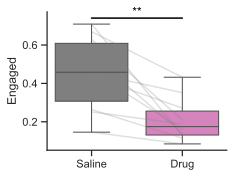

In [31]:
# Fraction of engagement
figsize = fig_size(n_cols=2)
plot_var_drug(df_behavior, var_name='Engaged', figsize=figsize)

State: t = 0.720, p = 0.490


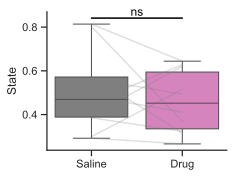

In [12]:
# Fraction of engagement
figsize = fig_size(n_cols=2)
plot_var_drug(df_behavior, var_name='State', figsize=figsize)

# Test

Engaged: t = 4.748, p = 0.001


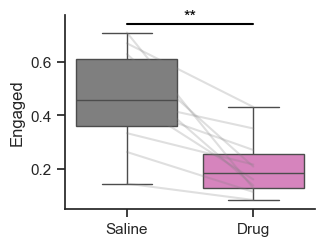

In [13]:
# Fraction of engagement (3 states, 2 covariates)
figsize = fig_size(n_cols=2)
plot_var_drug(df_behavior, var_name='Engaged', figsize=figsize)

Engaged: t = -0.492, p = 0.635


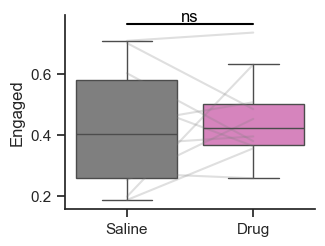

In [14]:
# Fraction of engagement (2 states, 3 covariates)
figsize = fig_size(n_cols=2)
plot_var_drug(df_behavior, var_name='Engaged', figsize=figsize)

## Licks

In [ ]:
def plot_ild_dist_mean_eng_drug(var='RT'):

    # Define conditions and titles
    conditions = [
        (0, 0),  # Disengaged - Saline
        (0, 1),  # Disengaged - Drug
        (1, 0),  # Engaged - Saline
        (1, 1)  # Engaged - Drug
    ]

    # Compute global y-limits
    all_means = []
    for engaged, drug in conditions:
        df = df_behavior[(df_behavior.Engaged==engaged) & (df_behavior.Drug==drug)]
        for ild in df_behavior.absILD.unique():
            all_means.append(df[df.absILD==ild][var].mean())
    y_min, y_max = min(all_means), max(all_means)
    y_ticks = np.linspace(y_min, y_max, 3)

    # Create 2x2 subplots
    fig, axes = plt.subplots(2, 2, figsize=default_figsize, constrained_layout=True)

    # Loop over conditions
    for engaged, drug in conditions:
        ax = axes[engaged, drug]
        plt.sca(ax)
        plot_ild_dist_mean(df_behavior[(df_behavior.Engaged == engaged) & (df_behavior.Drug == drug)], var=var)
        plt.ylim(None, y_max)
        # plt.yticks(y_ticks)

    # Set row labels
    axes[0, 0].set_ylabel('Disengaged')
    axes[1, 0].set_ylabel('Engaged')

    # Set column labels
    axes[0, 0].set_title('Saline')
    axes[0, 1].set_title('Drug')

    # Remove xlabels in 1st row
    axes[0, 0].set_xlabel('')
    axes[0, 1].set_xlabel('')

    # Remove titles in 2nd row
    axes[1, 0].set_title('')
    axes[1, 1].set_title('')

    # Remove ylabels in 2nd column
    axes[0, 1].set_ylabel('')
    axes[1, 1].set_ylabel('')

    plt.suptitle('Mean ' + var)

In [ ]:
def test(var='RT'):
    abs_ilds = sorted(df_behavior.absILD.unique())
    x = np.arange(len(abs_ilds))
    conditions = [
        (0, 0, 'tab:gray', '--', 'Dis.-Sal.'),
        # (0, 1, 'tab:pink', '--', 'Dis.-Drug'),
        (1, 0, 'tab:gray', '-', 'Eng.-Sal.'),
        # (1, 1, 'tab:pink', '-', 'Eng.-Drug')
    ]

    plt.figure(figsize=default_figsize)
    for engaged, drug, color, ls, label in conditions:
        df = df_behavior[(df_behavior.Engaged==engaged) & (df_behavior.Drug==drug)]
        means = [df[df.absILD==ild][var].mean() for ild in abs_ilds]
        sems = [df[df.absILD==ild][var].sem() for ild in abs_ilds]
        plt.errorbar(x, means, yerr=sems, marker='o', color=color, ls=ls, label=label)

    plt.xticks(x, [int(ild) for ild in abs_ilds])
    plt.xlabel('|ILD|')
    plt.ylabel(var)
    plt.legend()
    sns.despine()

### RTs

In [ ]:
plot_ild_dist_mean_eng_drug(var='RT')
test(var='RT')

In [ ]:
plot_ild_dist_mean_eng_drug(var='nLicks')
test(var='nLicks')

In [ ]:
plot_ild_dist_mean_eng_drug(var='ILI')
test(var='ILI')

# Serial dependence

Serial dependence requires a continuous readout of behavioral responses. As choices are binary (left/right), other readouts are needed. Let's try with reaction times (RT) and lick rate (nLicks)

In [ ]:
df = df_behavior

loc = df.columns.get_loc('Side') + 1
df.insert(loc, 'PreviousSide', df['Side'].shift(1))  # Add previous stimulus side column
loc = df.columns.get_loc('PreviousSide') + 1
df.insert(loc, 'RepSide', (df['Side'] == df['PreviousSide']).astype(int))  # Add repeating stimulus column
loc = df.columns.get_loc('ILD') + 1
df.insert(loc, 'PreviousILD', df['ILD'].shift(1))  # Add previous stimulus side column
loc = df.columns.get_loc('PreviousILD') + 1
df.insert(loc, 'DeltaILD', df.PreviousILD - df.ILD)  # Add previous stimulus side column
loc = df.columns.get_loc('DeltaILD') + 1
df.insert(loc, 'absDeltaILD', abs(df.DeltaILD))  # Add previous stimulus side column

# Filter data
df = df[df.Task == 'FD'].reset_index(drop=True)
df = df[df.P > 0].reset_index(drop=True)
df = df[df.Hit == 1].reset_index(drop=True)

# loc = df.columns.get_loc('nLicksRight') + 1  # Added to add_licks function
# df.insert(loc, 'nLicks', np.where(df['Side'] == 0, df['nLicksLeft'], df['nLicksRight']))  # Add number of licks column

# Center at 0 variables of interest
df.nLicks = df.nLicks - df.nLicks.mean()  # Substract its mean to nLicks
df.RT = df.RT - df.RT.mean()  # Substract its mean to RT
df.RT2 = df.RT2 - df.RT2.mean()  # Substract its mean to RT2

df.head()

In [ ]:
# Check value range of DeltaILD for binning later
np.array(sorted(df.DeltaILD.unique()))

In [ ]:
def plot_binned_deltaILD(var='RT', absolute=False):
    """
    Plot binned deltaILD distribution.
    :param var: variable to plot
    :param abs: if True, plot absolute values of deltaILD
    :return:
    """

    # Set bin edges
    if absolute:
        bins = [0, 5, 10, 20, 70, 80, 140]
        col_name = 'absDeltaILD'
        xlabel = 'abs(ΔILD)'
    else:
        bins = [-140, -80, -70, -20, -10, -5 , 5, 10, 20, 70, 80, 140]
        xlabel = 'ΔILD'
        col_name = 'DeltaILD'

    # Create bin labels ( as the bin spacing is not continuous)
    labels = [f"{bins[i]}:{bins[i+1]}" for i in range(len(bins)-1)]

    # Bin the data
    df['ILDbin'] = pd.cut(df[col_name], bins=bins, labels=labels, include_lowest=True)

    # Group and compute means
    mean_licks = df.groupby('ILDbin', as_index=False)[var].mean()

    # Plot
    plt.figure(constrained_layout=True)
    plt.bar(mean_licks['ILDbin'], mean_licks[var], color='tab:gray')
    plt.xlabel(xlabel)
    plt.ylabel(var)
    plt.xticks(rotation=45)
    plt.title(f'{var} by {xlabel}')
    sns.despine()

### Measured as Reaction Times (RTs)

In [ ]:
# Plot mean RT split by RepSide
plt.figure(constrained_layout=True)
sns.kdeplot(df[df.RepSide==0].RT, label='rep_stim', color='tab:purple')
sns.kdeplot(df[df.RepSide==1].RT, label='alt_stim', color='tab:brown')
plt.title('RT distribution')
# plt.legend(frameon=False)
sns.despine()

# Plot means in inset plot
ax = plt.gca()  # get current axes
ax_inset = inset_axes(ax, width='30%', height='30%', loc='upper right')
sns.pointplot(data=df, x='RepSide', y='RT', hue='RepSide', markers='o', palette=['tab:purple', 'tab:brown'], linestyles='', legend=False)
plt.xticks([0, 1], ['Alt', 'Rep'])
plt.xlabel('Stim')

# Run t-test
var_name = 'RT'
alt_stim = df[df['RepSide'] == 0][var_name]
rep_stim = df[df['RepSide'] == 1][var_name]
t_stat, p_val = ttest_ind(alt_stim, rep_stim)
print(f"{var_name}: t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")
add_star_between(p_val)
sns.despine()

#### ΔILD

In [ ]:
# Plot the RT by Δ change in ILD (previous-current)
plt.figure(constrained_layout=True)
plt.plot(df.groupby('DeltaILD').RT.mean(), marker='o', color='tab:gray')
plt.xlabel('ΔILD')
plt.ylabel('RT')
plt.title('RT by ΔILD')
sns.despine()

plot_binned_deltaILD(var='RT', absolute=False)

##### Absolute ΔILD

In [ ]:
# Plot the RT by absolute Δ change in ILD (previous-current)
plt.figure(constrained_layout=True)
plt.plot(df.groupby('absDeltaILD').RT.mean(), marker='o', color='tab:gray')
plt.xlabel('abs(ΔILD)')
plt.ylabel('RT')
plt.title('RT by abs(ΔILD)')
sns.despine()

plot_binned_deltaILD(var='RT', absolute=True)

### Measured as N licks

In [ ]:
# Plot mean RT split by RepSide
plt.figure(constrained_layout=True)
sns.kdeplot(df[df.RepSide==0].nLicks, label='rep_stim', color='tab:purple')
sns.kdeplot(df[df.RepSide==1].nLicks, label='alt_stim', color='tab:brown')
plt.title('N licks distribution')
# plt.legend(frameon=False)

# Plot means in inset plot
ax = plt.gca()  # get current axes
ax_inset = inset_axes(ax, width='30%', height='30%', loc='upper right')
sns.pointplot(data=df, x='RepSide', y='nLicks', hue='RepSide', markers='o', palette=['tab:purple', 'tab:brown'], linestyles='', legend=False)
plt.xticks([0, 1], ['Alt', 'Rep'])
plt.xlabel('Stim')
sns.despine()

# Run t-test
var_name = 'nLicks'
alt_stim = df[df['RepSide'] == 0][var_name]
rep_stim = df[df['RepSide'] == 1][var_name]
t_stat, p_val = ttest_ind(alt_stim, rep_stim)
print(f"{var_name}: t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")
add_star_between(p_val)
sns.despine()

#### ΔILD

In [ ]:
# Plot the number of licks by Δ change in ILD (previous-current)
plt.figure(constrained_layout=True)
plt.plot(df.groupby('DeltaILD').nLicks.mean(), marker='o', color='tab:gray')
plt.xlabel('ΔILD')
plt.ylabel('nLicks')
plt.title('nLicks by ΔILD')
sns.despine()

plot_binned_deltaILD(var='nLicks', absolute=False)

##### Absolute ΔILD

In [ ]:
# Plot the number of licks by absolute Δ change in ILD (previous-current)
plt.figure(constrained_layout=True)
plt.plot(df.groupby('absDeltaILD').nLicks.mean(), marker='o', color='tab:gray')
plt.xlabel('abs(ΔILD)')
plt.ylabel('nLicks')
plt.title('nLicks by abs(ΔILD)')
sns.despine()

plot_binned_deltaILD(var='nLicks', absolute=True)

# Save all notebook's figures

In [146]:
# # Whole notebook ouputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt

# Export all figures
# save_notebook_files('notebook.ipynb')

Saved 34 images to notebook_files/
